# Senti-Recommend: Exploratory Data Analysis
### PGD Data Science Final Project
**Dataset:** AI Tools — Metadata & User Reviews  
**Objective:** Understand data structure, quality, distributions, and derive insights to inform a Hybrid Collaborative-Filtering + Sentiment Recommendation Engine

---

## 1. Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Data

In [2]:
meta    = pd.read_csv('../data/raw/ai_tools_metadata.csv')
reviews = pd.read_csv('../data/raw/ai_tools_reviews.csv')

print(f'Metadata   -> {meta.shape[0]:,} apps  x {meta.shape[1]} columns')
print(f'Reviews    -> {reviews.shape[0]:,} rows x {reviews.shape[1]} columns')

Metadata   -> 482 apps  x 30 columns
Reviews    -> 69,727 rows x 13 columns


In [3]:
meta.head(3)

,app_id,app_name,developer,category_scraped,project_category,avg_rating,total_ratings,total_reviews,installs,description,...,free,url,icon_url,genre_id,ratings_1_star,ratings_2_star,ratings_3_star,ratings_4_star,ratings_5_star,scraped_at
0,ai.chat.gpt.bot,ChatOn - AI Chat Bot Assistant,AIBY Inc.,Productivity,Generative Text / Chatbots,4.530914,415843,4815,28956985,Welcome to the world of AI assistance! Meet Ch...,...,True,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/p8Q9Nc4A...,PRODUCTIVITY,24512,6145,19548,39404,326193,2026-02-21T09:26:23.205626
1,com.scaleup.chatai,AI Chatbot - Nova,ScaleUp,Productivity,Generative Text / Chatbots,3.817843,2099272,24702,88953865,Nova is a revolutionary AI chatbot and persona...,...,True,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/xDCktRsb...,PRODUCTIVITY,472745,63909,110348,178184,1274041,2026-02-21T09:26:26.039446
2,com.codespaceapps.aichat,Chatbot AI - Search Assistant,Codespace Dijital,Productivity,Generative Text / Chatbots,4.386683,853354,3558,43643439,Welcome to the world of AI assistance! Meet Ch...,...,True,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/oG6s8oEa...,PRODUCTIVITY,76628,17701,38039,87567,633364,2026-02-21T09:26:28.472949


In [4]:
reviews.head(3)

,app_id,review_id,user_name,review_text,review_title,star_rating,thumbs_up_count,review_date,reply_text,reply_date,app_version_review,sort_source,scraped_at
0,ai.chat.gpt.bot,67119987-51f4-44b1-bc96-65d9ac7b74f9,Leafand Lotus,"Weak. Can't upload images for reference, the a...",NaN,1,5,2026-02-03 20:36:24,Hello! Thank you for your feedback. We'd appre...,2026-02-09 16:42:08,NaN,relevant,2026-02-21T09:50:35.531042
1,ai.chat.gpt.bot,39f0ae17-5bb6-462c-976c-497a468e6d71,Hayden Winn,It has lower models and only allows 5 free pro...,NaN,1,7,2026-01-08 03:40:33,NaN,NaN,NaN,relevant,2026-02-21T09:50:35.531081
2,ai.chat.gpt.bot,28426411-3f9f-4d26-b4eb-14fb027297e9,Jenn,it's a little tricky sometimes to get the righ...,NaN,5,922,2024-09-09 23:16:54,NaN,NaN,1.49.432-480,relevant,2026-02-21T09:50:35.531093


## 3. Data Quality Audit

In [5]:
# 3.1 Missing values in metadata
missing_meta = (
    meta.isnull().sum()
    .rename('null_count')
    .to_frame()
    .assign(pct=lambda d: (d['null_count'] / len(meta) * 100).round(1))
    .query('null_count > 0')
    .sort_values('pct', ascending=False)
)
print('=== Metadata: columns with nulls ===')
print(missing_meta)

=== Metadata: columns with nulls ===
                 null_count    pct
android_version         482  100.0
size                    482  100.0
updated_on               34    7.1
released_on               3    0.6


In [6]:
# 3.2 Missing values in reviews
missing_rev = (
    reviews.isnull().sum()
    .rename('null_count')
    .to_frame()
    .assign(pct=lambda d: (d['null_count'] / len(reviews) * 100).round(1))
    .query('null_count > 0')
    .sort_values('pct', ascending=False)
)
print('=== Reviews: columns with nulls ===')
print(missing_rev)

=== Reviews: columns with nulls ===
                    null_count    pct
review_title             69727  100.0
reply_text               48355   69.3
reply_date               48355   69.3
app_version_review        9867   14.2
user_name                    2    0.0
review_text                  1    0.0


In [7]:
# 3.3 Duplicate check
print(f"Duplicate app_ids  (metadata) : {meta['app_id'].duplicated().sum()}")
print(f"Duplicate review_ids (reviews): {reviews['review_id'].duplicated().sum()}")

Duplicate app_ids  (metadata) : 0
Duplicate review_ids (reviews): 0


In [8]:
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   app_id            482 non-null    object 
 1   app_name          482 non-null    object 
 2   developer         482 non-null    object 
 3   category_scraped  482 non-null    object 
 4   project_category  482 non-null    object 
 5   avg_rating        482 non-null    float64
 6   total_ratings     482 non-null    int64  
 7   total_reviews     482 non-null    int64  
 8   installs          482 non-null    int64  
 9   description       482 non-null    object 
 10  summary           482 non-null    object 
 11  content_rating    482 non-null    object 
 12  android_version   0 non-null      float64
 13  app_version       482 non-null    object 
 14  updated_on        448 non-null    float64
 15  released_on       479 non-null    object 
 16  size              0 non-null      float64
 1

In [9]:
meta.describe().round(2)

,avg_rating,total_ratings,total_reviews,installs,android_version,updated_on,size,price_usd,ratings_1_star,ratings_2_star,ratings_3_star,ratings_4_star,ratings_5_star
count,482.00,4.820000e+02,482.00,4.820000e+02,0.0,4.480000e+02,0.0,482.00,482.00,482.00,482.00,482.00,4.820000e+02
mean,4.26,1.156713e+06,23201.31,1.711635e+08,NaN,1.764683e+09,NaN,0.01,92086.41,21563.33,43889.10,100587.32,8.985562e+05
std,0.49,9.352064e+06,224453.88,1.234183e+09,NaN,1.213735e+07,NaN,0.21,744285.16,172338.70,370142.00,822845.04,7.387654e+06
min,1.80,1.500000e+01,0.00,4.570000e+02,NaN,1.684536e+09,NaN,0.00,0.00,0.00,0.00,0.00,0.000000e+00
25%,4.08,8.707500e+02,20.25,7.650925e+04,NaN,1.763406e+09,NaN,0.00,67.25,13.25,33.25,86.25,6.087500e+02
50%,4.38,9.458000e+03,190.50,6.685205e+05,NaN,1.769754e+09,NaN,0.00,698.50,143.50,350.00,707.00,7.138500e+03
75%,4.58,9.847275e+04,1703.25,7.196744e+06,NaN,1.770993e+09,NaN,0.00,8085.25,1854.25,3874.25,10394.00,7.422500e+04
max,5.00,1.788879e+08,4280976.00,1.915867e+10,NaN,1.771657e+09,NaN,3.49,11570933.00,2504723.00,6845342.00,15901334.00,1.436351e+08


## 4. Metadata EDA

### 4.1 Project Category Distribution
> How many AI tools fall into each of the five project categories?

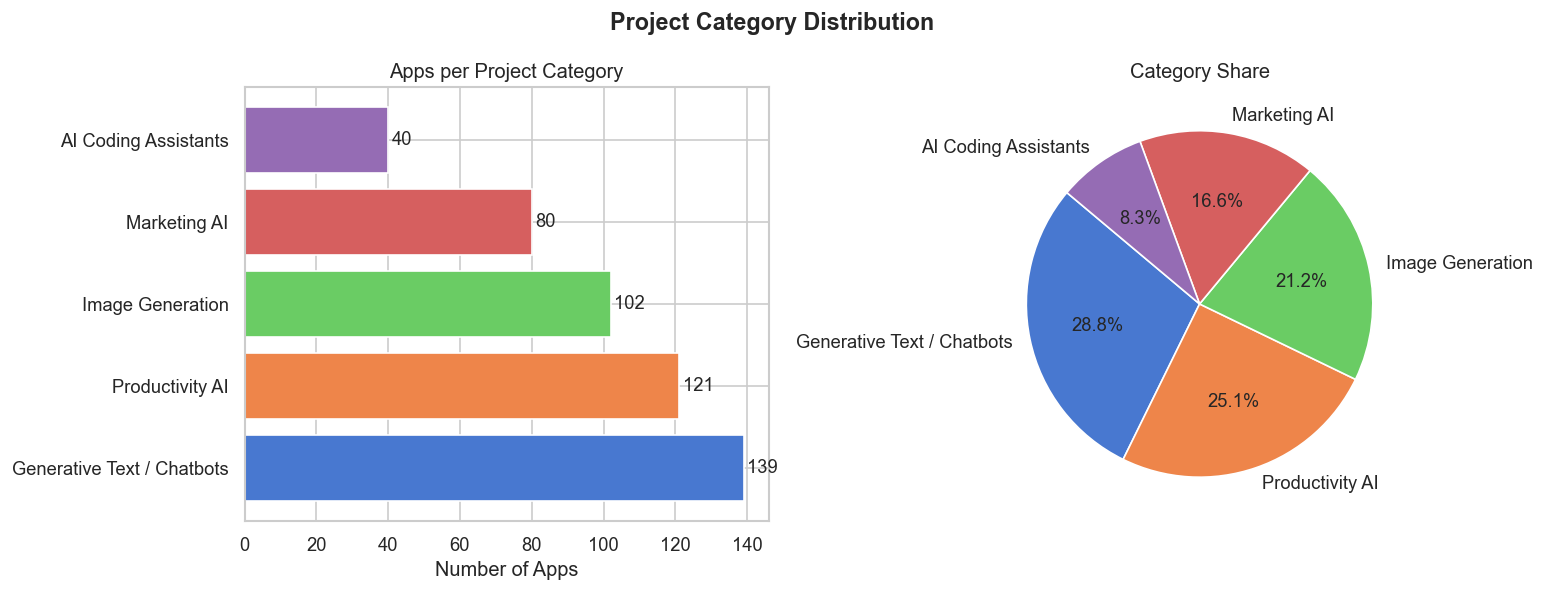

project_category
Generative Text / Chatbots    139
Productivity AI               121
Image Generation              102
Marketing AI                   80
AI Coding Assistants           40
Name: count, dtype: int64


In [10]:
cat_counts = meta['project_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].barh(cat_counts.index, cat_counts.values,
             color=sns.color_palette('muted', len(cat_counts)))
axes[0].set_xlabel('Number of Apps')
axes[0].set_title('Apps per Project Category')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 1, i, str(v), va='center')

# Pie
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(cat_counts)))
axes[1].set_title('Category Share')

plt.suptitle('Project Category Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(cat_counts)

### 4.2 Pricing Model Distribution

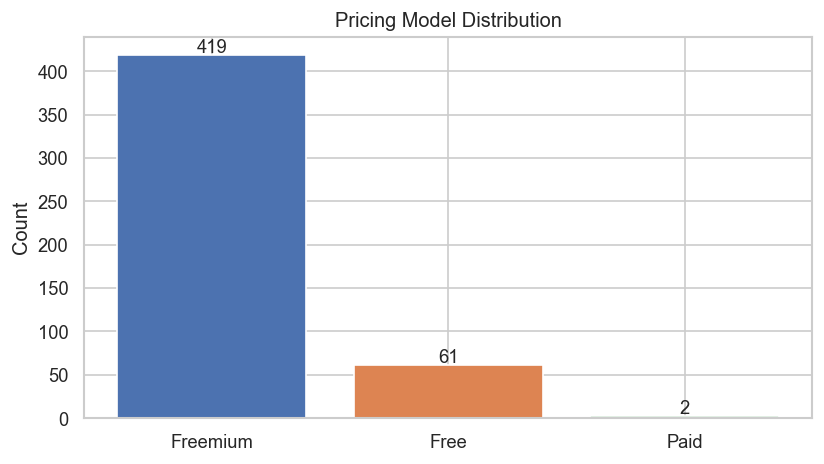

In [11]:
price_counts = meta['pricing_model'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(price_counts.index, price_counts.values,
              color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylabel('Count')
ax.set_title('Pricing Model Distribution')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            str(int(bar.get_height())), ha='center')
plt.tight_layout()
plt.show()

### 4.3 Average Rating Distribution

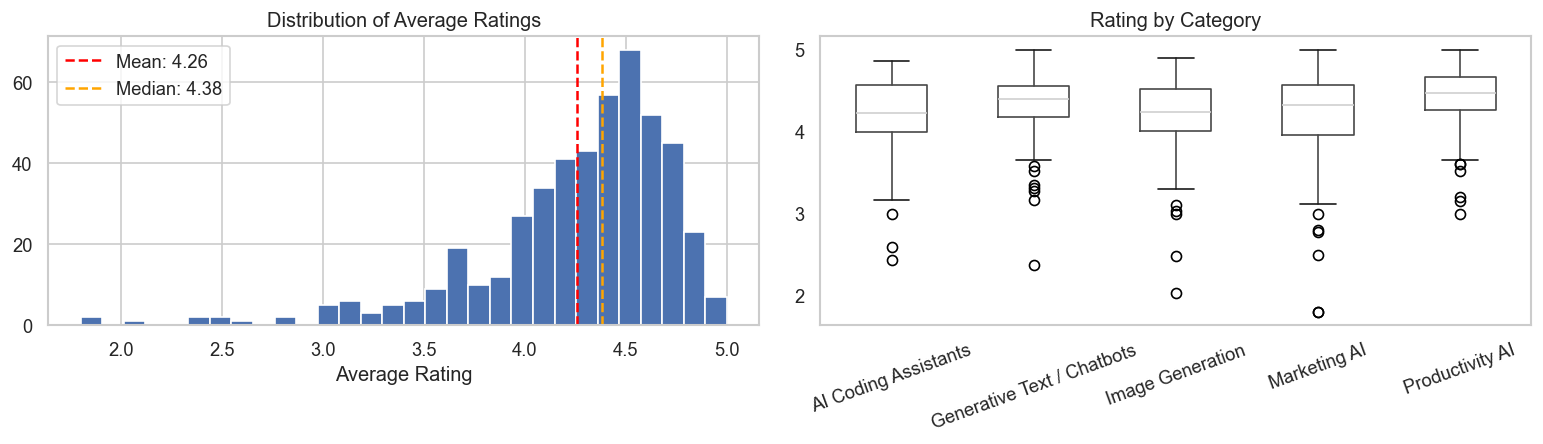

count    482.000000
mean       4.258544
std        0.490511
min        1.800000
25%        4.075556
50%        4.379769
75%        4.580000
max        5.000000
Name: avg_rating, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(meta['avg_rating'].dropna(), bins=30,
             color='#4C72B0', edgecolor='white')
axes[0].axvline(meta['avg_rating'].mean(), color='red', linestyle='--',
                label=f"Mean: {meta['avg_rating'].mean():.2f}")
axes[0].axvline(meta['avg_rating'].median(), color='orange', linestyle='--',
                label=f"Median: {meta['avg_rating'].median():.2f}")
axes[0].set_xlabel('Average Rating')
axes[0].set_title('Distribution of Average Ratings')
axes[0].legend()

meta.boxplot(column='avg_rating', by='project_category',
             ax=axes[1], grid=False)
axes[1].set_title('Rating by Category')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('')
plt.tight_layout()
plt.show()

print(meta['avg_rating'].describe())

### 4.4 Installs Distribution (Log Scale)

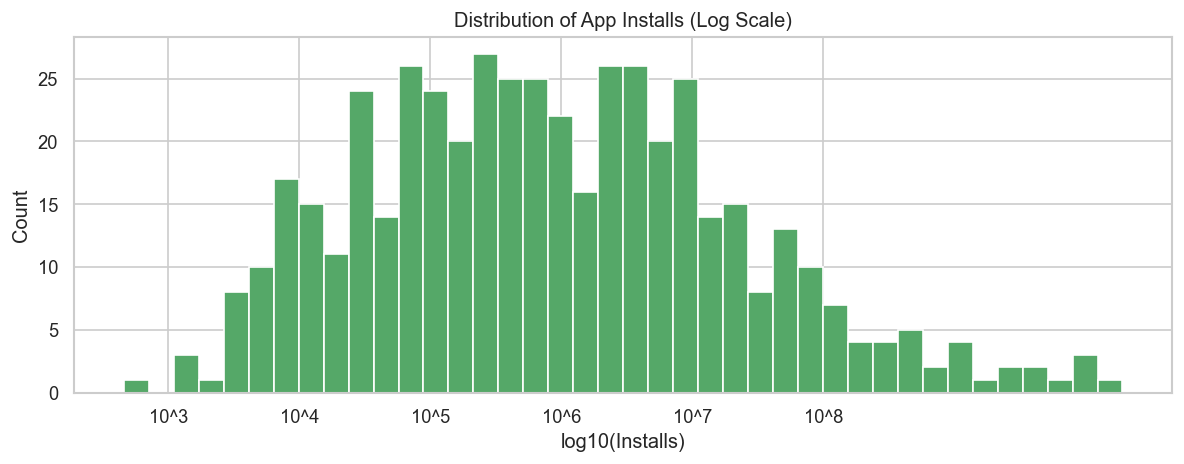

count    4.820000e+02
mean     1.711635e+08
std      1.234183e+09
min      4.570000e+02
25%      7.650925e+04
50%      6.685205e+05
75%      7.196744e+06
max      1.915867e+10
Name: installs, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
log_installs = np.log10(meta['installs'].replace(0, np.nan).dropna())
ax.hist(log_installs, bins=40, color='#55A868', edgecolor='white')
ax.set_xlabel('log10(Installs)')
ax.set_ylabel('Count')
ax.set_title('Distribution of App Installs (Log Scale)')
ticks = [3, 4, 5, 6, 7, 8]
ax.set_xticks(ticks)
ax.set_xticklabels([f'10^{t}' for t in ticks])
plt.tight_layout()
plt.show()

print(meta['installs'].describe())

### 4.5 Top 15 Most-Installed Apps

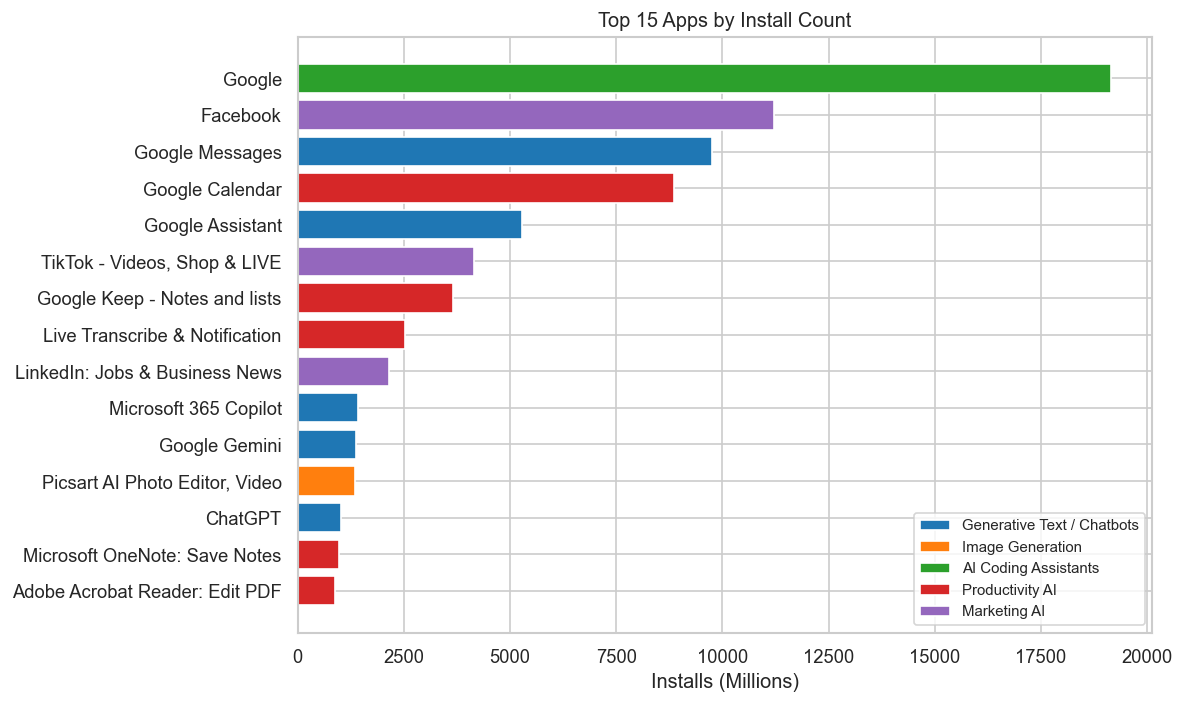

In [14]:
top15 = meta.nlargest(15, 'installs')[['app_name', 'project_category', 'installs', 'avg_rating']]

fig, ax = plt.subplots(figsize=(10, 6))
cats = meta['project_category'].unique()
colors = sns.color_palette('tab10', len(cats))
cat_color_map = dict(zip(cats, colors))

ax.barh(top15['app_name'],
        top15['installs'] / 1e6,
        color=[cat_color_map[c] for c in top15['project_category']])
ax.set_xlabel('Installs (Millions)')
ax.set_title('Top 15 Apps by Install Count')
ax.invert_yaxis()

legend_elements = [mpatches.Patch(facecolor=v, label=k) for k, v in cat_color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 4.6 Rating Heatmap — Category x Pricing Model

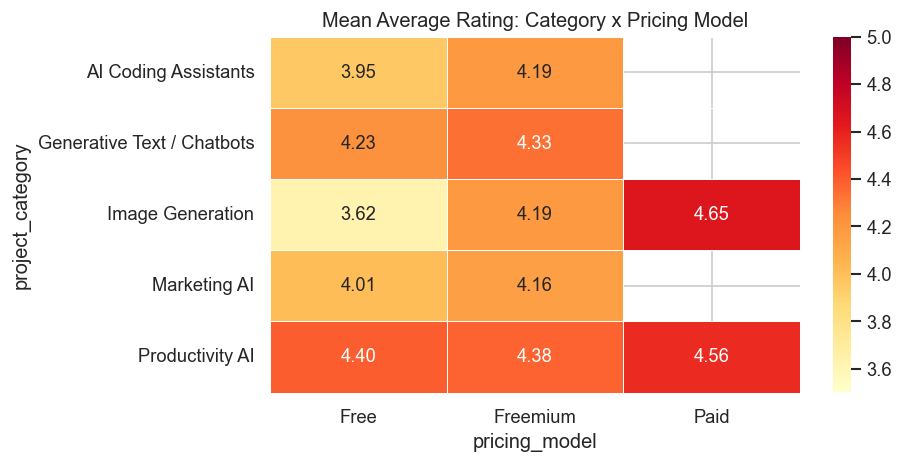

In [15]:
pivot = meta.pivot_table(values='avg_rating',
                          index='project_category',
                          columns='pricing_model',
                          aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=3.5, vmax=5.0)
ax.set_title('Mean Average Rating: Category x Pricing Model')
plt.tight_layout()
plt.show()

### 4.7 Star Rating Breakdown per Category (Stacked Bar)

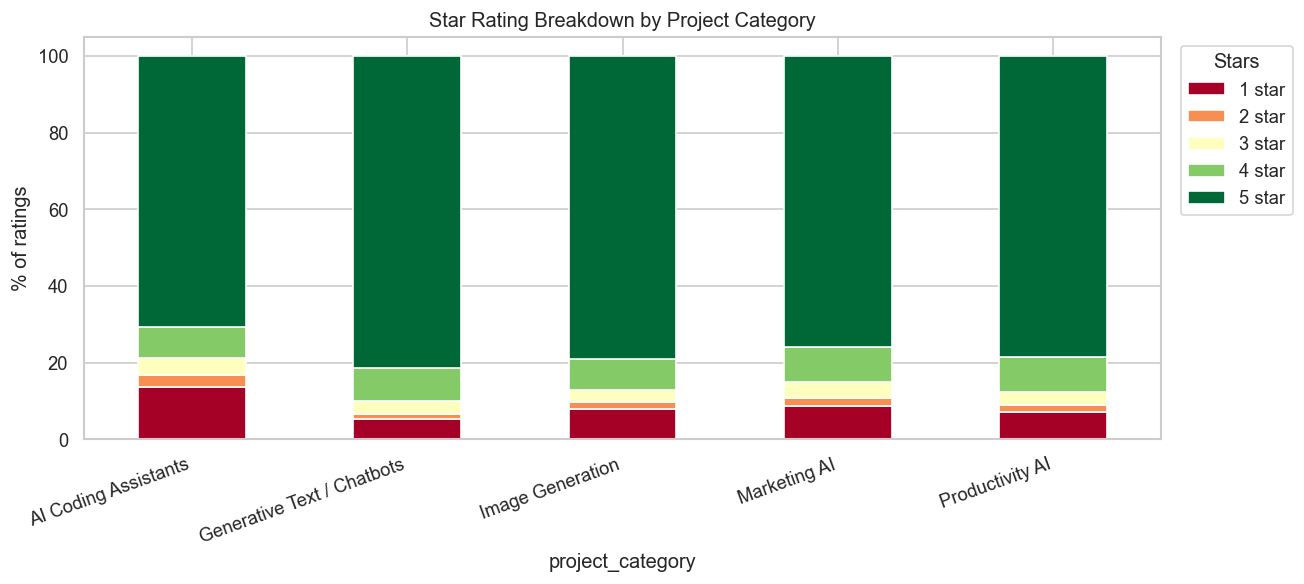

In [16]:
star_cols = ['ratings_1_star','ratings_2_star','ratings_3_star',
             'ratings_4_star','ratings_5_star']
star_by_cat = meta.groupby('project_category')[star_cols].sum()
star_pct = star_by_cat.div(star_by_cat.sum(axis=1), axis=0) * 100
star_pct.columns = ['1 star','2 star','3 star','4 star','5 star']

ax = star_pct.plot(kind='bar', stacked=True, figsize=(11, 5),
                   colormap='RdYlGn')
ax.set_ylabel('% of ratings')
ax.set_title('Star Rating Breakdown by Project Category')
ax.legend(bbox_to_anchor=(1.01, 1), title='Stars')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 4.8 Scatter: Installs vs. Average Rating

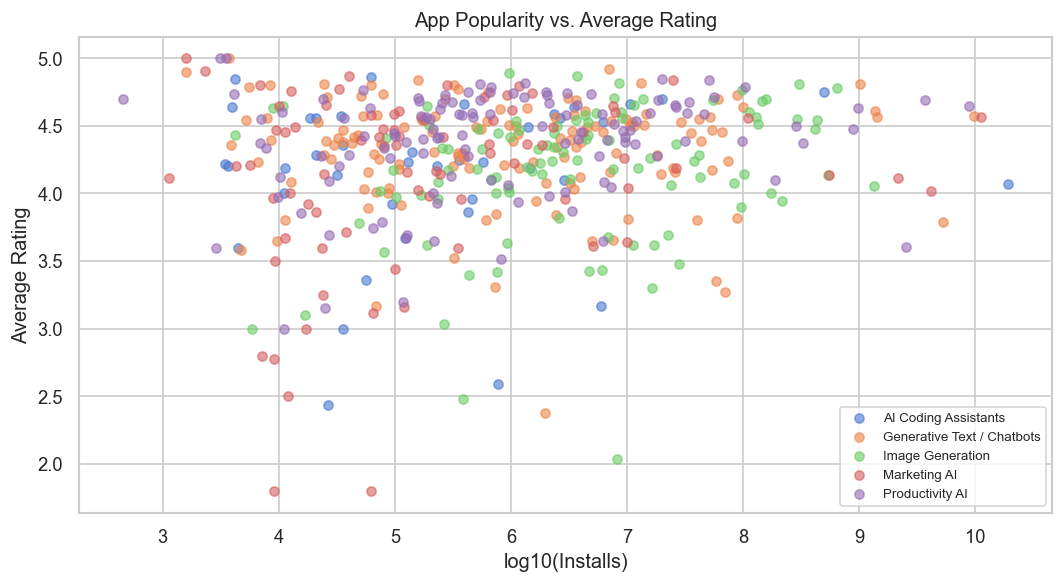

Correlation matrix:
               installs  avg_rating  total_ratings  total_reviews
installs          1.000       0.020          0.604          0.566
avg_rating        0.020       1.000          0.052          0.025
total_ratings     0.604       0.052          1.000          0.963
total_reviews     0.566       0.025          0.963          1.000


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
for cat, grp in meta.groupby('project_category'):
    ax.scatter(np.log10(grp['installs'].replace(0, np.nan)),
               grp['avg_rating'],
               label=cat, alpha=0.6, s=30)

ax.set_xlabel('log10(Installs)')
ax.set_ylabel('Average Rating')
ax.set_title('App Popularity vs. Average Rating')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

corr = meta[['installs','avg_rating','total_ratings','total_reviews']].corr()
print('Correlation matrix:')
print(corr.round(3))

## 5. Reviews EDA

### 5.1 Star Rating Distribution Across All Reviews

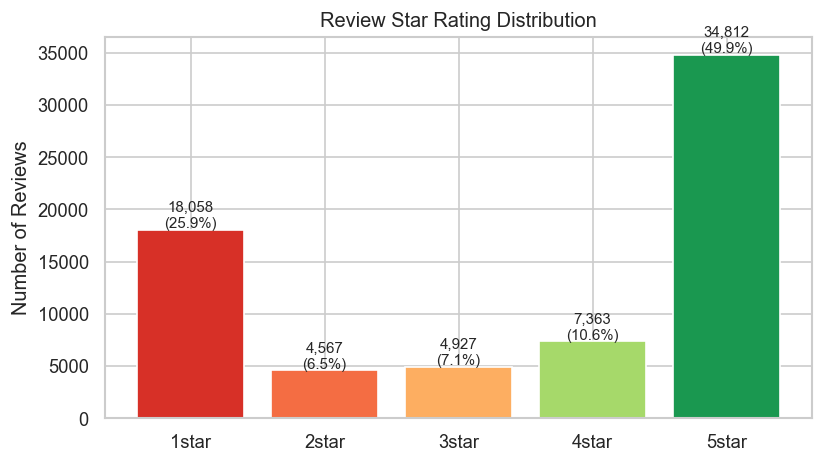

In [18]:
star_dist = reviews['star_rating'].value_counts().sort_index()
total = star_dist.sum()

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['#d73027','#f46d43','#fdae61','#a6d96a','#1a9850']
bars = ax.bar([str(s)+'star' for s in star_dist.index],
              star_dist.values, color=bar_colors)
ax.set_ylabel('Number of Reviews')
ax.set_title('Review Star Rating Distribution')
for bar, v in zip(bars, star_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{v:,}\n({v/total*100:.1f}%)',
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Merge Reviews with Metadata & Review Volume per Category

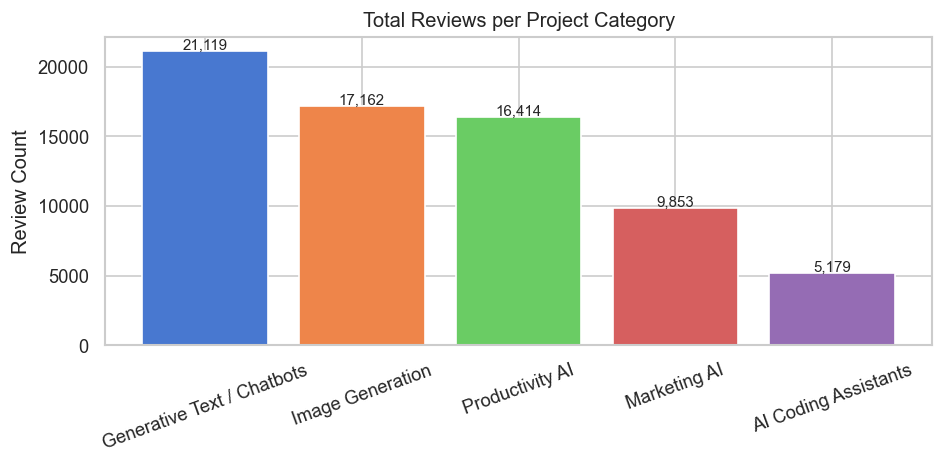

In [19]:
# Merge to get category info alongside reviews
rev_meta = reviews.merge(
    meta[['app_id','project_category','pricing_model']],
    on='app_id', how='left'
)

cat_rev = rev_meta['project_category'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cat_rev.index, cat_rev.values,
       color=sns.color_palette('muted', len(cat_rev)))
ax.set_ylabel('Review Count')
ax.set_title('Total Reviews per Project Category')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(cat_rev.values):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Average Star Rating by Category (from Review Text)

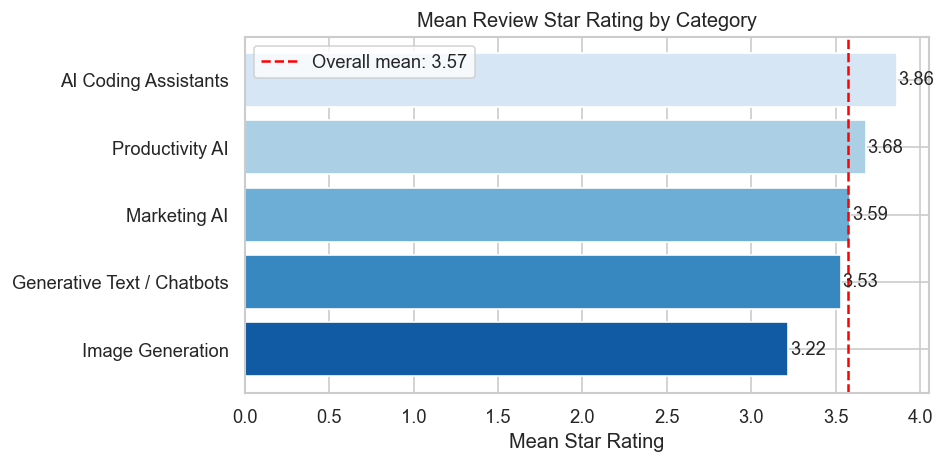

In [20]:
avg_star_cat = rev_meta.groupby('project_category')['star_rating'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(avg_star_cat.index, avg_star_cat.values,
               color=sns.color_palette('Blues_r', len(avg_star_cat)))
ax.axvline(avg_star_cat.mean(), color='red', linestyle='--',
           label=f'Overall mean: {avg_star_cat.mean():.2f}')
ax.set_xlabel('Mean Star Rating')
ax.set_title('Mean Review Star Rating by Category')
ax.legend()
for bar in bars:
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center')
plt.tight_layout()
plt.show()

### 5.4 Review Length Analysis

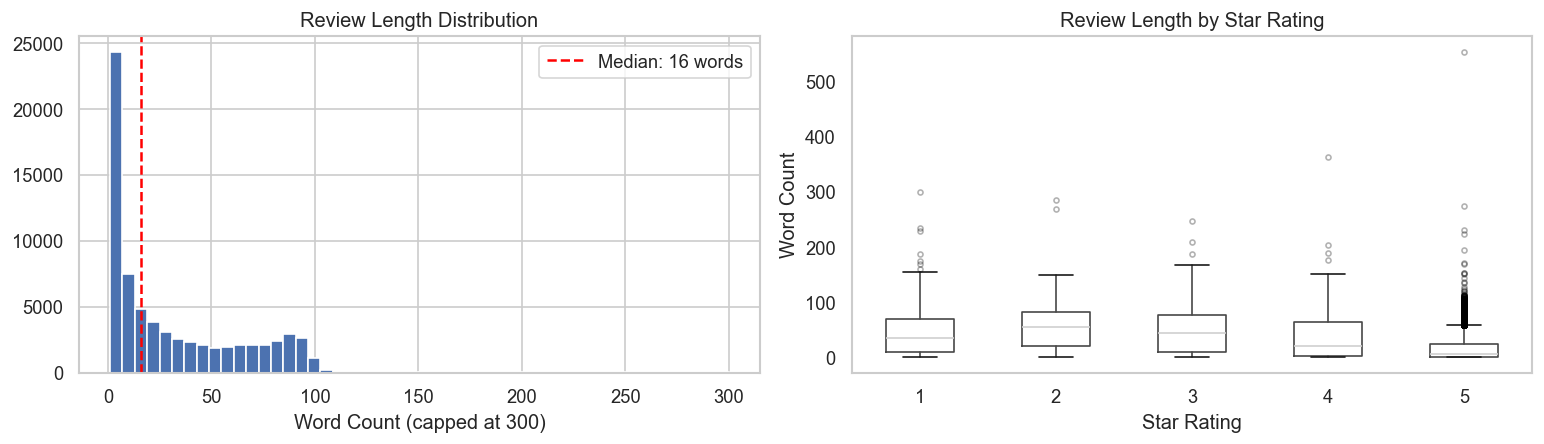

               count  mean   std  min   25%   50%   75%    max
star_rating                                                   
1            18057.0  41.2  31.9  1.0  11.0  35.0  70.0  299.0
2             4567.0  51.9  32.5  1.0  21.0  56.0  82.0  285.0
3             4927.0  45.1  34.4  1.0  10.0  44.0  77.5  248.0
4             7363.0  34.5  33.3  1.0   4.0  22.0  65.0  362.0
5            34812.0  19.0  25.8  1.0   2.0   6.0  25.0  553.0


In [21]:
rev_meta['review_length'] = rev_meta['review_text'].dropna().apply(
    lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(rev_meta['review_length'].dropna().clip(upper=300),
             bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Word Count (capped at 300)')
axes[0].set_title('Review Length Distribution')
axes[0].axvline(rev_meta['review_length'].median(), color='red', linestyle='--',
                label=f"Median: {rev_meta['review_length'].median():.0f} words")
axes[0].legend()

rev_meta.boxplot(column='review_length', by='star_rating',
                 ax=axes[1], grid=False,
                 flierprops=dict(marker='.', alpha=0.3))
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Word Count')
axes[1].set_title('Review Length by Star Rating')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(rev_meta.groupby('star_rating')['review_length'].describe().round(1))

### 5.5 Review Volume Over Time (Monthly Trend)

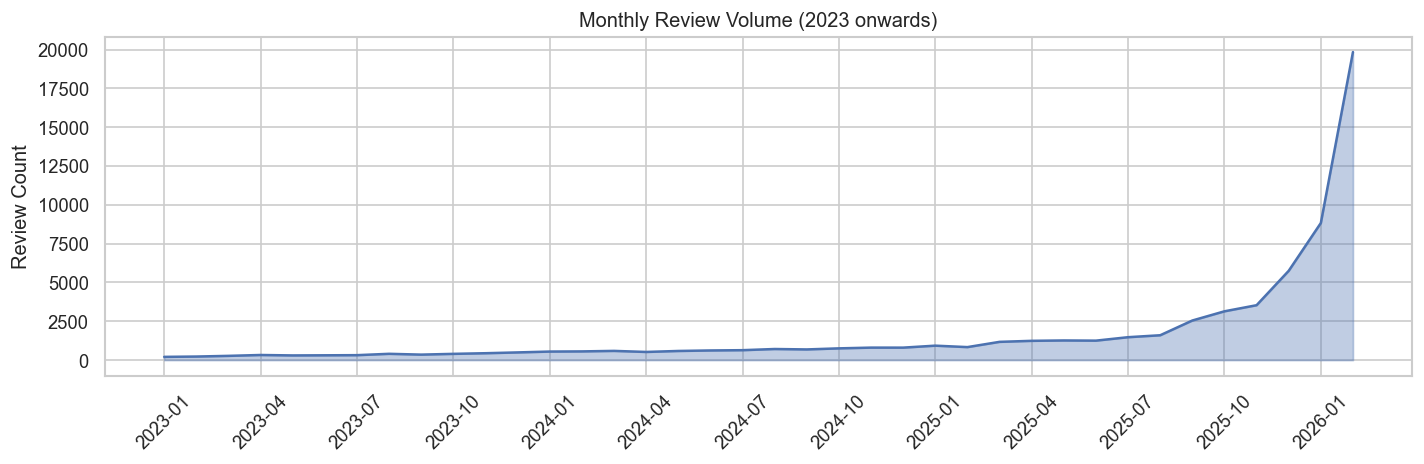

In [22]:
rev_meta['review_date'] = pd.to_datetime(rev_meta['review_date'], errors='coerce')
rev_meta['year_month']  = rev_meta['review_date'].dt.to_period('M')

monthly = (rev_meta.groupby('year_month').size()
           .reset_index(name='count')
           .sort_values('year_month'))

# Filter to post-2023 for clarity
recent = monthly[monthly['year_month'] >= '2023-01']

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(recent))
ax.fill_between(x, recent['count'].values, alpha=0.35, color='#4C72B0')
ax.plot(x, recent['count'].values, color='#4C72B0')
ax.set_xticks(range(0, len(recent), 3))
ax.set_xticklabels([str(p) for p in recent['year_month'].values[::3]], rotation=45)
ax.set_ylabel('Review Count')
ax.set_title('Monthly Review Volume (2023 onwards)')
plt.tight_layout()
plt.show()

### 5.6 Developer Response Rate by Category

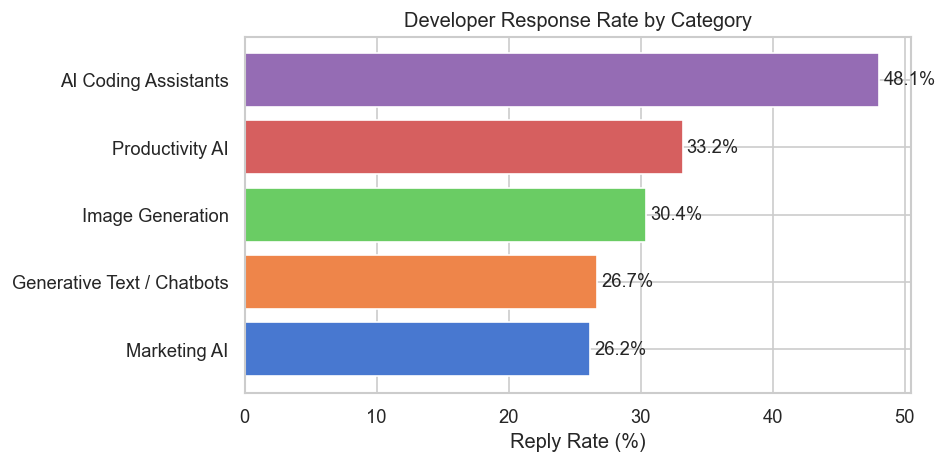

In [23]:
rev_meta['has_reply'] = rev_meta['reply_text'].notna().astype(int)

reply_rate = (
    rev_meta.groupby('project_category')['has_reply']
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(reply_rate.index, reply_rate.values,
               color=sns.color_palette('muted', len(reply_rate)))
ax.set_xlabel('Reply Rate (%)')
ax.set_title('Developer Response Rate by Category')
for bar in bars:
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center')
plt.tight_layout()
plt.show()

### 5.7 Top 15 Apps by Review Count

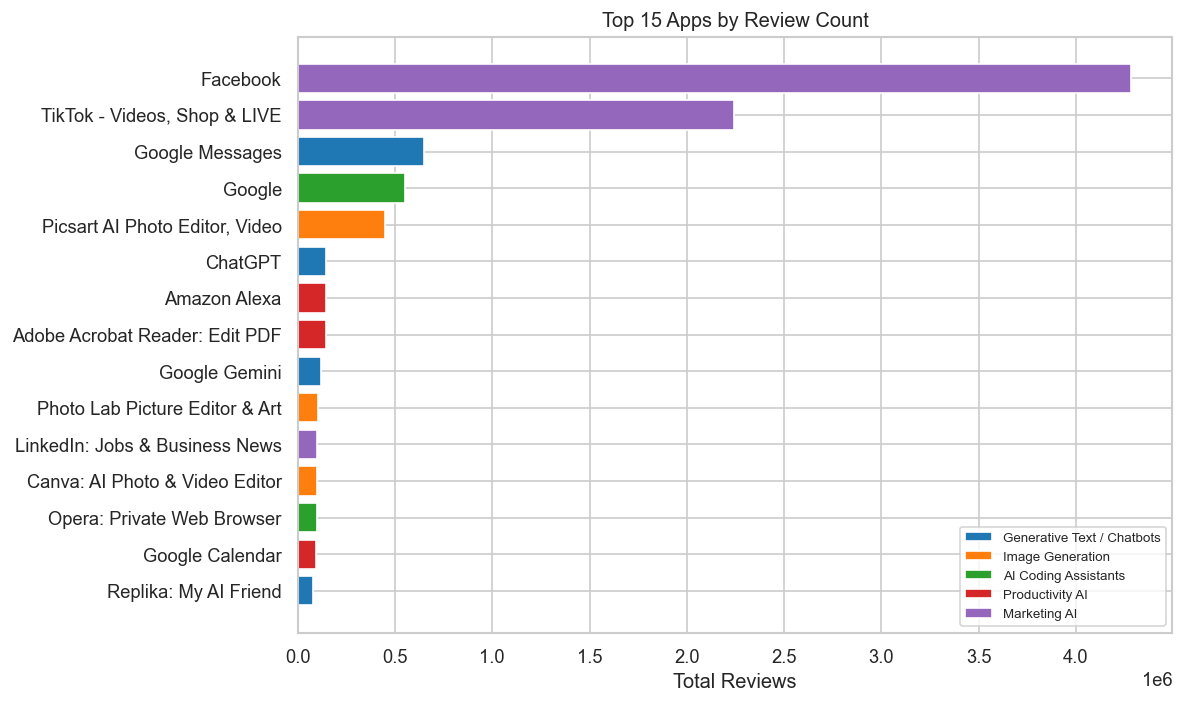

In [24]:
top_reviewed = meta.nlargest(15, 'total_reviews')[['app_name','project_category','total_reviews','avg_rating']]

fig, ax = plt.subplots(figsize=(10, 6))
cats2 = meta['project_category'].unique()
colors2 = sns.color_palette('tab10', len(cats2))
cat_map2 = dict(zip(cats2, colors2))

ax.barh(top_reviewed['app_name'],
        top_reviewed['total_reviews'],
        color=[cat_map2[c] for c in top_reviewed['project_category']])
ax.set_xlabel('Total Reviews')
ax.set_title('Top 15 Apps by Review Count')
ax.invert_yaxis()

legend2 = [mpatches.Patch(facecolor=v, label=k) for k, v in cat_map2.items()]
ax.legend(handles=legend2, fontsize=8)
plt.tight_layout()
plt.show()

## 6. Sentiment Analysis Preview (VADER)

> VADER (Valence Aware Dictionary and sEntiment Reasoner) assigns a compound score between -1 (most negative) and +1 (most positive) to each review.  
> Install with: `pip install vaderSentiment`

In [25]:
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    VADER_AVAILABLE = True
    print('VADER is available.')
except ImportError:
    VADER_AVAILABLE = False
    print('vaderSentiment not installed. Run: pip install vaderSentiment')
    print('Skipping VADER cells. Re-run after installation.')

vaderSentiment not installed. Run: pip install vaderSentiment
Skipping VADER cells. Re-run after installation.


In [26]:
if VADER_AVAILABLE:
    sia = SentimentIntensityAnalyzer()
    # Sample 5,000 reviews for speed — adjust as needed
    sample = (
        rev_meta[['app_id','review_text','star_rating','project_category']]
        .dropna(subset=['review_text'])
        .sample(5000, random_state=42)
    )
    sample['vader_compound'] = sample['review_text'].apply(
        lambda t: sia.polarity_scores(str(t))['compound'])
    sample['vader_label'] = sample['vader_compound'].apply(
        lambda s: 'Positive' if s >= 0.05 else ('Negative' if s <= -0.05 else 'Neutral'))
    print('VADER label distribution:')
    print(sample['vader_label'].value_counts())

In [27]:
if VADER_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].hist(sample['vader_compound'], bins=50, color='#4C72B0', edgecolor='white')
    axes[0].axvline(0.05,  color='green', linestyle='--', label='Positive threshold')
    axes[0].axvline(-0.05, color='red',   linestyle='--', label='Negative threshold')
    axes[0].set_xlabel('VADER Compound Score')
    axes[0].set_title('Distribution of Sentiment Scores')
    axes[0].legend()

    sample.boxplot(column='vader_compound', by='star_rating',
                   ax=axes[1], grid=False,
                   flierprops=dict(marker='.', alpha=0.2))
    axes[1].set_xlabel('Star Rating')
    axes[1].set_ylabel('VADER Compound Score')
    axes[1].set_title('Sentiment Score vs Star Rating')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

In [28]:
if VADER_AVAILABLE:
    sent_cat = sample.groupby('project_category')['vader_compound'].mean().sort_values()
    fig, ax = plt.subplots(figsize=(8, 4))
    bar_clrs = ['#d73027' if v < 0 else '#1a9850' for v in sent_cat.values]
    bars = ax.barh(sent_cat.index, sent_cat.values, color=bar_clrs)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean VADER Compound Score')
    ax.set_title('Average Sentiment by Project Category')
    for bar in bars:
        ax.text(bar.get_width() + 0.003,
                bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center')
    plt.tight_layout()
    plt.show()

## 7. Identifying Hidden Gems

> A 'hidden gem' is an app with a **high average rating** but **low total review count** — likely underrated or under-discovered.  
> These are prime targets for the Senti-Recommend engine to surface.

In [29]:
# Wilson Lower Bound — penalises apps with few reviews even if highly rated
def wilson_lower_bound(pos, n, z=1.96):
    if n == 0: return 0.0
    phat = pos / n
    return (
        phat + z**2/(2*n)
        - z * np.sqrt((phat*(1-phat) + z**2/(4*n)) / n)
    ) / (1 + z**2/n)

meta['approx_pos']    = meta['ratings_4_star'] + meta['ratings_5_star']
meta['wilson_score']  = meta.apply(
    lambda r: wilson_lower_bound(r['approx_pos'], r['total_ratings']), axis=1)

# Hidden gems: top-quartile avg_rating AND bottom-quartile reviews
q75_rating  = meta['avg_rating'].quantile(0.75)
q25_reviews = meta['total_reviews'].quantile(0.25)

gems = meta[
    (meta['avg_rating']   >= q75_rating) &
    (meta['total_reviews'] <= q25_reviews)
].sort_values('avg_rating', ascending=False)

print(f'Hidden Gems found: {len(gems)}')
print(f'Criteria: avg_rating >= {q75_rating:.2f}  AND  total_reviews <= {q25_reviews:.0f}')
gems[['app_name','project_category','avg_rating','total_reviews','pricing_model']].head(15)

Hidden Gems found: 29
Criteria: avg_rating >= 4.58  AND  total_reviews <= 20


,app_name,project_category,avg_rating,total_reviews,pricing_model
50,AI Academic Writing Assistant,Generative Text / Chatbots,5.000000,0,Freemium
352,AI Calendar - 1 Line Scheduler,Productivity AI,5.000000,5,Free
302,NoteLyn: AI Note Taker & Study,Productivity AI,5.000000,1,Freemium
470,Product Plus: AI Product Photo,Marketing AI,5.000000,1,Freemium
469,AI Description Generator,Marketing AI,4.909091,7,Freemium
8,AI ChatBot Assistant,Generative Text / Chatbots,4.894737,6,Freemium
458,Tags Buddy Pro tags finder SEO,Marketing AI,4.869565,11,Freemium
258,AI Code Generator,AI Coding Assistants,4.846154,7,Freemium
122,Email Writer: AI Generator,Generative Text / Chatbots,4.810000,11,Free
432,AI Caption Generator Writer,Marketing AI,4.800000,2,Freemium


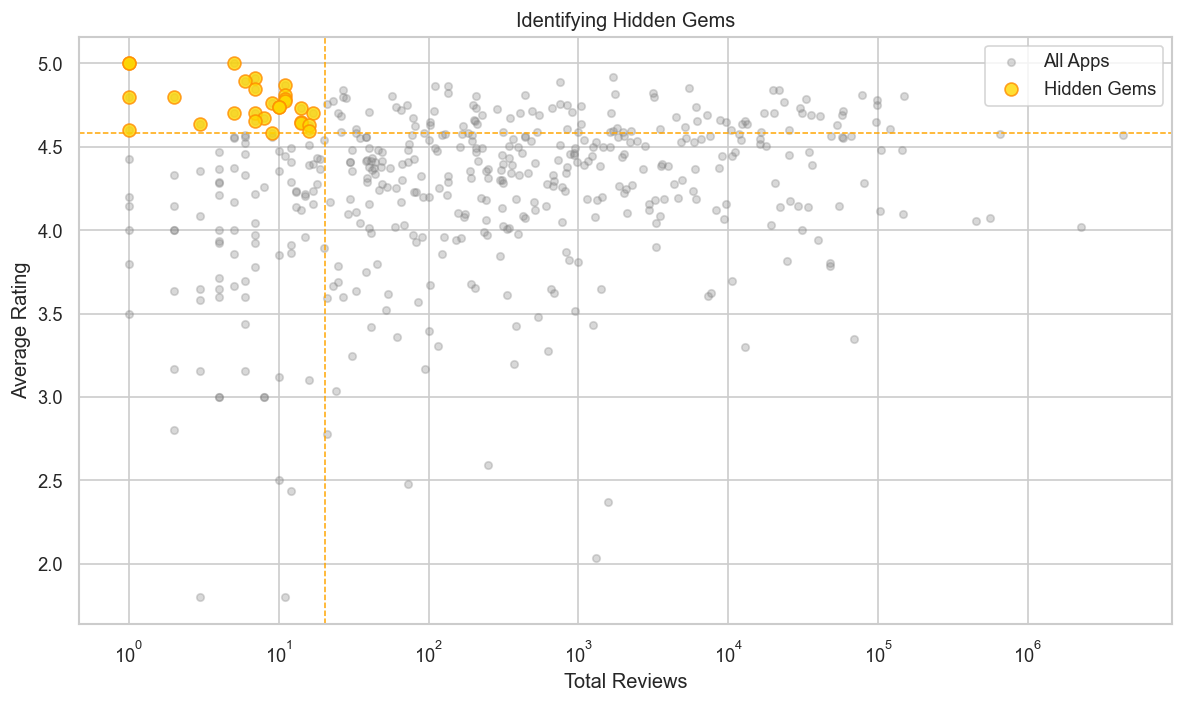

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(meta['total_reviews'], meta['avg_rating'],
           alpha=0.3, s=20, color='grey', label='All Apps')
ax.scatter(gems['total_reviews'], gems['avg_rating'],
           alpha=0.8, s=60, color='gold',
           edgecolors='darkorange', zorder=5, label='Hidden Gems')
ax.axvline(q25_reviews, color='orange', linestyle='--', linewidth=0.9)
ax.axhline(q75_rating,  color='orange', linestyle='--', linewidth=0.9)
ax.set_xlabel('Total Reviews')
ax.set_ylabel('Average Rating')
ax.set_title('Identifying Hidden Gems')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

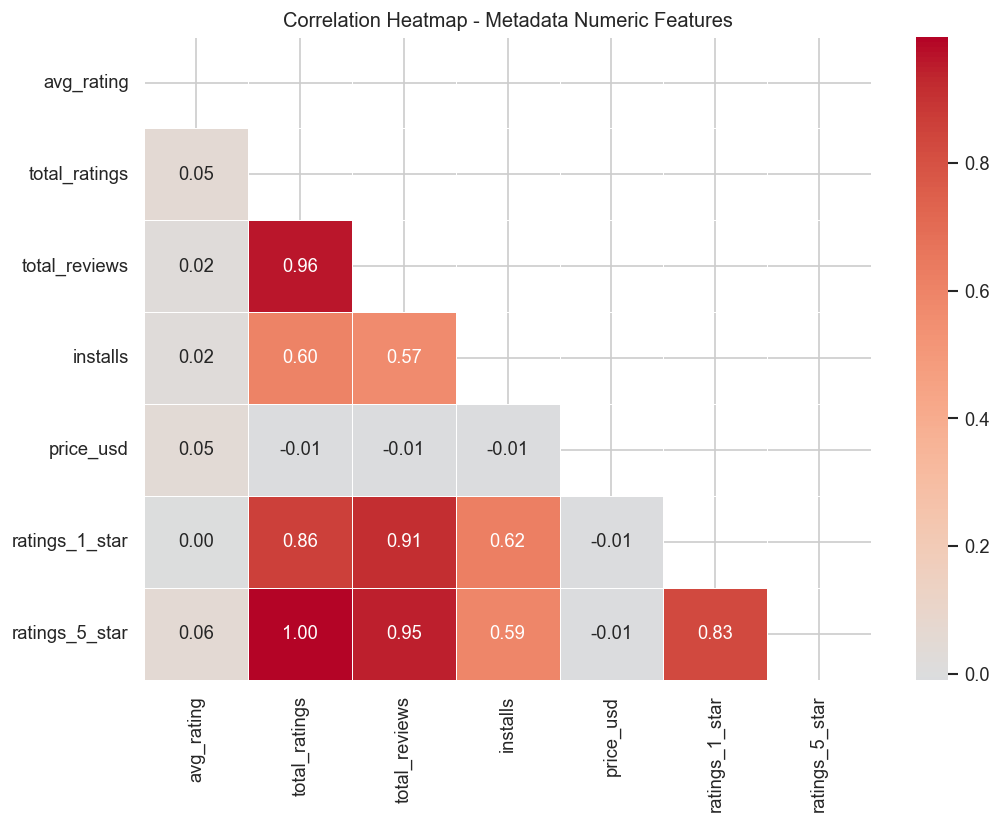

In [31]:
numeric_cols = ['avg_rating','total_ratings','total_reviews',
                'installs','price_usd',
                'ratings_1_star','ratings_5_star']

corr_matrix = meta[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap - Metadata Numeric Features')
plt.tight_layout()
plt.show()

## 9. Cold-Start Analysis

> Apps with very few reviews cannot rely on Collaborative Filtering.  
> We need a Knowledge-Based fallback strategy for these.

In [32]:
cold_start = meta[meta['total_reviews'] <= 5].copy()
print(f'Apps with 5 or fewer reviews: {len(cold_start)}')
print()
print('Breakdown by category:')
print(cold_start['project_category'].value_counts())
print()
print('Breakdown by pricing model:')
print(cold_start['pricing_model'].value_counts())

Apps with 5 or fewer reviews: 51

Breakdown by category:
project_category
Marketing AI                  18
Productivity AI               14
Generative Text / Chatbots    10
AI Coding Assistants           6
Image Generation               3
Name: count, dtype: int64

Breakdown by pricing model:
pricing_model
Freemium    38
Free        13
Name: count, dtype: int64


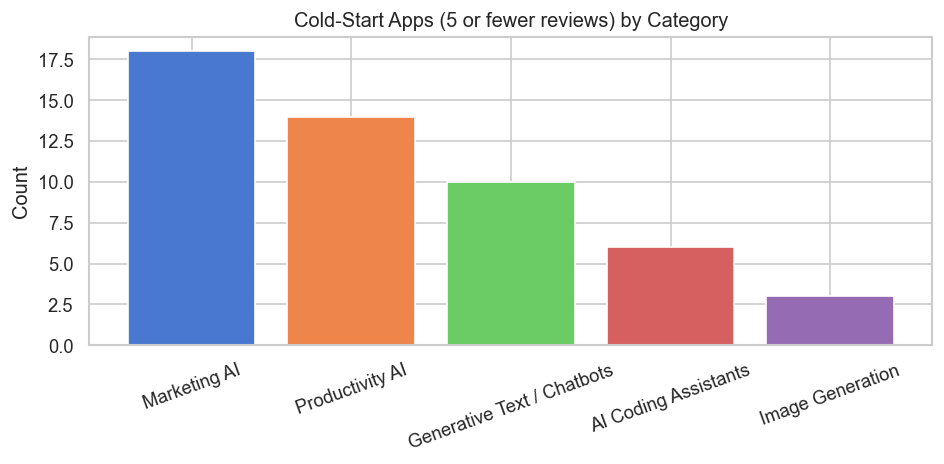

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
cold_cat = cold_start['project_category'].value_counts()
ax.bar(cold_cat.index, cold_cat.values,
       color=sns.color_palette('muted', len(cold_cat)))
ax.set_ylabel('Count')
ax.set_title('Cold-Start Apps (5 or fewer reviews) by Category')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 10. Key EDA Findings & Recommendations

| # | Finding | Implication for Senti-Recommend |
|---|---------|----------------------------------|
| 1 | **Generative Text** has the most apps (139 / 29%) | Heaviest focus for CF training |
| 2 | **Freemium dominates** (87% of apps) | Pricing model weakly discriminates; use `offers_iap` flag |
| 3 | **J-shaped star distribution** in reviews (5-star and 1-star dominate) | VADER compound score will uncover nuance stars cannot |
| 4 | **Longer reviews** for 1-star ratings | Negative reviews carry richer textual signal; weight VADER accordingly |
| 5 | **Low correlation** between installs and avg_rating | Popularity does not equal quality; validates the hybrid approach |
| 6 | **Hidden gems** identified (high rating, low reviews) | Wilson score + sentiment will surface underrated tools |
| 7 | **Cold-start apps** exist across all categories | Knowledge-based fallback is essential |
| 8 | **Developer reply rate varies** by category | Reply presence is a useful metadata feature for trust scoring |

---

### Next Steps for the Project

1. **Text Preprocessing** — lowercase, remove HTML/emojis, strip stop-words from review text  
2. **Full VADER Run** — assign a `user_satisfaction_score` to all 69K+ reviews  
3. **Aspect-Based Sentiment** — detect feelings toward *Ease of Use*, *Pricing Fairness*, *Customer Support*  
4. **Build CF Interaction Matrix** — user x app from star ratings using Surprise / SVD  
5. **Hybrid Fusion** — weighted blend: `Final Score = alpha * CF_score + (1-alpha) * VADER_score`  
6. **Streamlit Dashboard** — real-time discovery UI accepting natural-language queries  
